# Applied Artificial Intelligence Coursework
#### Submitted by Sarah Ojo

### American Sign Language Prediction with Convolutional Neural Network

The dataset is the Mavi and Dickle (2022) found online at https://www.kaggle.com/ardamavi/27-class-sign-language-dataset. The data has been saved in my D drive and I will load it into the jupyter notebook from there

#### Import the Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore')


# to load the data
import tensorflow as tf                    
from tensorflow import keras                              

# to preprocess the data
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from keras.utils import to_categorical

# To construct the model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.optimizers import Adam

# Print the confusion matrix and classification report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

import os

import random

#### Load the data set

In [3]:
#load the data from the same directory
x = np.load("X_ASL.npy")
y = np.load("Y_ASL.npy")

#### Splitting the data into training, testing and validation

In [4]:
## Splitting the dataset into training testing and validation data
my_seed = 42
split_proportion = 0.1  #split using 10%
# shuffle and split the data
split_number = int(split_proportion * x.shape[0])

np.random.seed(my_seed)
np.random.shuffle(x) #employ random so it can  shuffle the data
x_val = tf.convert_to_tensor(x[:split_number]) # the  first 10% using the index number
x_test = tf.convert_to_tensor(x[split_number:2*split_number]) # the next 10%
x_train = tf.convert_to_tensor(x[2*split_number:]) # the remaining 80%

np.random.seed(my_seed)
np.random.shuffle(y)
y_val = tf.convert_to_tensor(y[:split_number])
y_test = tf.convert_to_tensor(y[split_number:2*split_number])
y_train = tf.convert_to_tensor(y[2*split_number:])

I will print the labels and put them into a dictionary with the index as the key and the labels as the values

In [5]:
label_dict = {}

for number, label in enumerate(np.unique(y_train)):
    label_dict[number] = label
    
print(label_dict, x.shape)

{0: b'0', 1: b'1', 2: b'2', 3: b'3', 4: b'4', 5: b'5', 6: b'6', 7: b'7', 8: b'8', 9: b'9', 10: b'NULL', 11: b'a', 12: b'b', 13: b'bye', 14: b'c', 15: b'd', 16: b'e', 17: b'good', 18: b'good morning', 19: b'hello', 20: b'little bit', 21: b'no', 22: b'pardon', 23: b'please', 24: b'project', 25: b'whats up', 26: b'yes'} (22801, 128, 128, 3)


In [6]:
reverse_label_dict = {}
for key in label_dict.keys():
    reverse_label_dict[label_dict[key]] = key
    
print(reverse_label_dict)

{b'0': 0, b'1': 1, b'2': 2, b'3': 3, b'4': 4, b'5': 5, b'6': 6, b'7': 7, b'8': 8, b'9': 9, b'NULL': 10, b'a': 11, b'b': 12, b'bye': 13, b'c': 14, b'd': 15, b'e': 16, b'good': 17, b'good morning': 18, b'hello': 19, b'little bit': 20, b'no': 21, b'pardon': 22, b'please': 23, b'project': 24, b'whats up': 25, b'yes': 26}


Preproces the data - reshaping

In [7]:
np_train_y = np.zeros_like(y_train) # , dtype=tf.int32)
np_val_y = np.zeros_like(y_val)
np_test_y = np.zeros_like(y_test)

for ii in range(np_train_y.shape[0]):
    np_train_y[ii] = reverse_label_dict[y_train[ii].numpy()[0]]
    
for ii in range(np_val_y.shape[0]):
    np_val_y[ii] = reverse_label_dict[y_val[ii].numpy()[0]]
    
for ii in range(np_test_y.shape[0]):
    np_test_y[ii] = reverse_label_dict[y_test[ii].numpy()[0]]
    
y_train = tf.convert_to_tensor(np_train_y.reshape(-1), dtype=tf.int32)
y_val = tf.convert_to_tensor(np_val_y.reshape(-1), dtype=tf.int32)
y_test = tf.convert_to_tensor(np_test_y.reshape(-1), dtype=tf.int32)

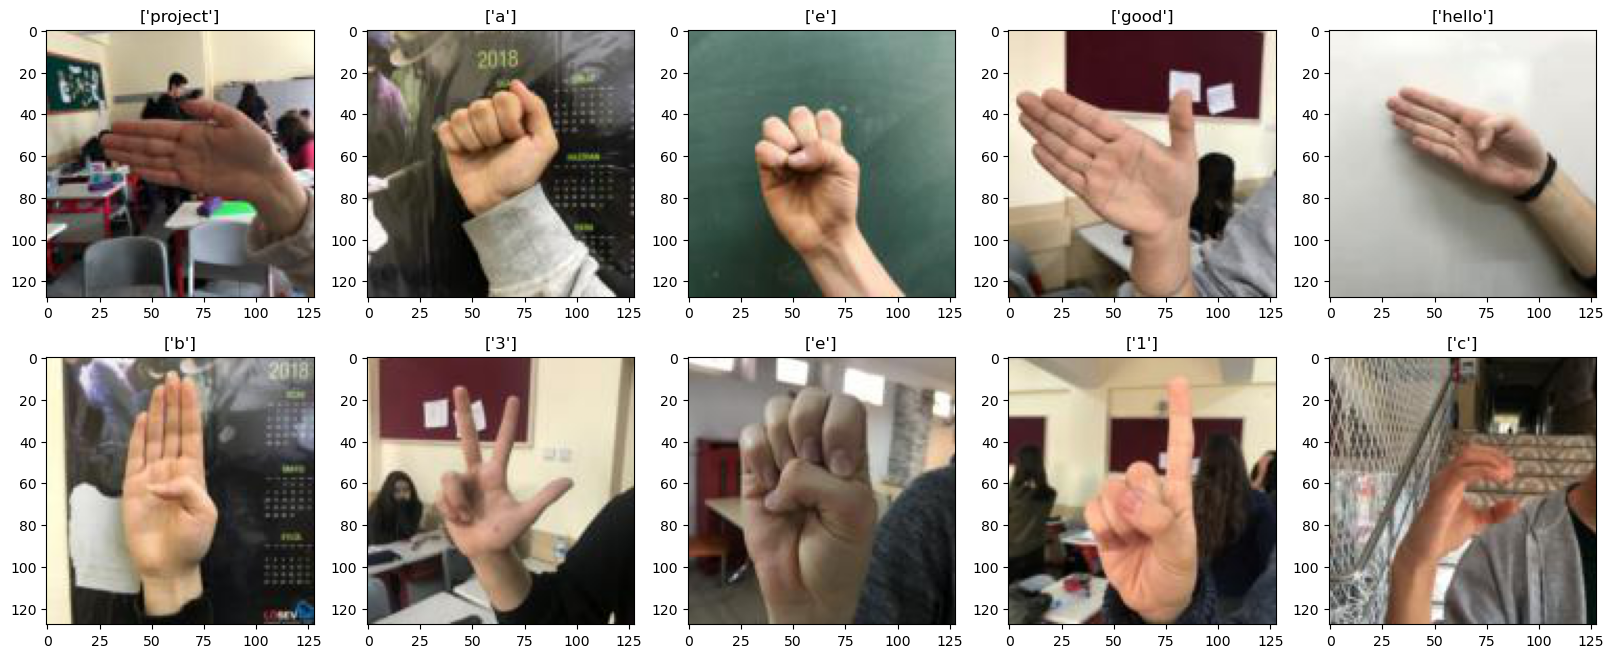

In [9]:
plt.figure(figsize=(20, 6))
for i, index in enumerate(random.sample(range(x.shape[0]), 10)):
    plt.subplot(2, 5, i + 1)
    plt.subplots_adjust(top=2, bottom=1)
    plt.imshow(x[index])
    plt.title(y[index])
    
    plt.show

In [10]:
# I will print the shape of the data

print("x_train shape: ",x_train.shape)
print("x_test shape: ", x_test.shape)
print("y_train shape: ",y_train.shape)
print("y_test shape: ", y_test.shape)

x_train shape:  (18241, 128, 128, 3)
x_test shape:  (2280, 128, 128, 3)
y_train shape:  (18241,)
y_test shape:  (2280,)


#### Data Augmentation

In [14]:
#For preprocessing, the ImageDataGenerator is used. 
#It is used for the generation of batches of augmented image data 
#in real-time during the training process;

# Define data augmentation parameters for training set
train_datagen = ImageDataGenerator(
 rotation_range=20, # Randomly rotate images up to 10 degrees
 width_shift_range=0.1, # Randomly shift images horizontally up to 10% of the width
 height_shift_range=0.1, # Randomly shift images vertically up to 10% of the height
 horizontal_flip=False, # Don't andomly flip images horizontally
 vertical_flip=False, # Don't randomly flip images vertically
 shear_range=0.10, # crops part of the image
 zoom_range=0.10 # #zooms the image by 10%
)

In [15]:
# Fit the transformation to the training dataset
train_datagen.fit(x_train)

In [111]:
from tensorflow.python.ops.numpy_ops import np_config
np_config.enable_numpy_behavior()

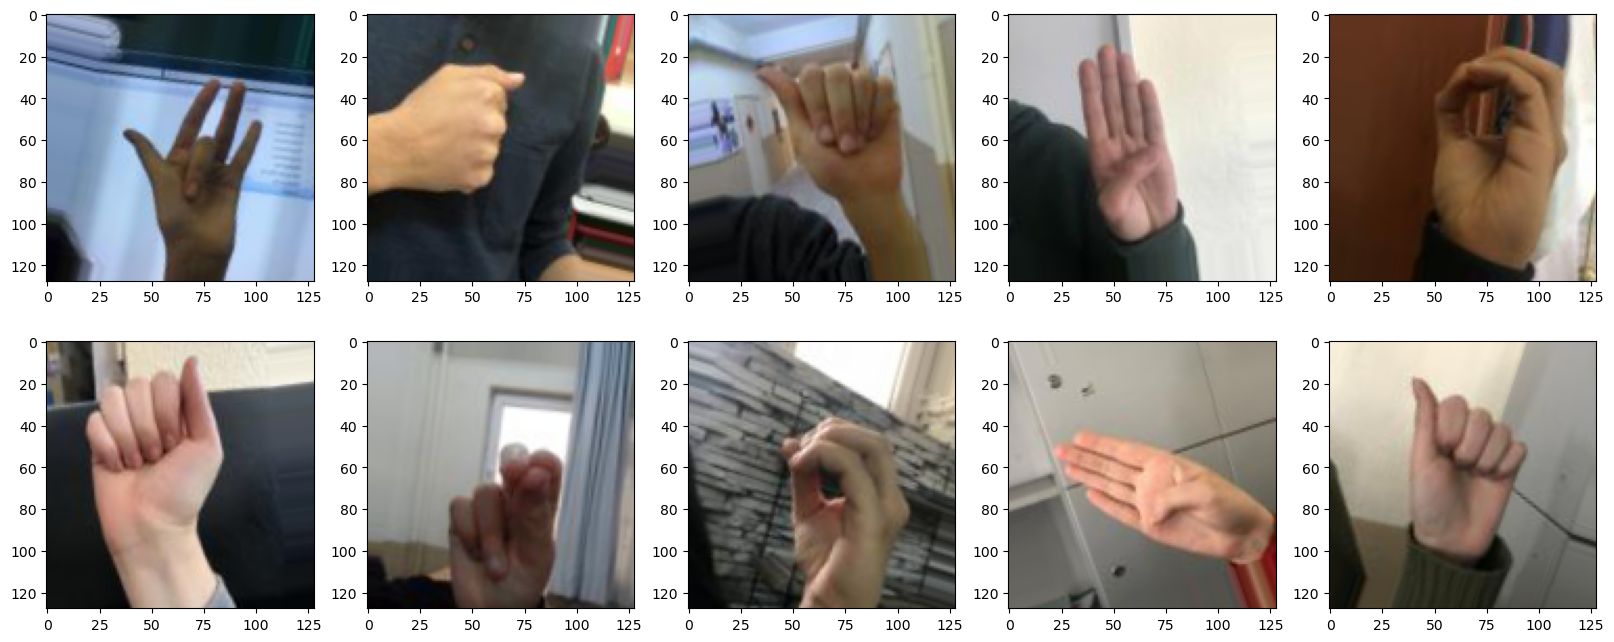

In [120]:
# print samples from the augmented data
    

plt.figure(figsize=(20, 6))
for i, index in enumerate(range(10)):  # Iterate over the first 10 indices
    augmented_image = train_datagen.random_transform(x_train[index])  # Apply augmentation
    plt.subplot(2, 5, i + 1)
    plt.subplots_adjust(top=2, bottom=1)
    plt.imshow(augmented_image)
plt.show()

In [16]:
#Number of classes which will serve as output shape
number_classes = len(label_dict.keys())

### Model Building

#### Baseline Model

In [99]:
# Create Model
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (3,3), padding = 'Same', activation = 'relu', input_shape = (x_train.shape[1:])))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(filters = 32, kernel_size = (3,3), padding = 'Same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(filters = 64, kernel_size = (3,3), padding = 'Same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = 'Same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(128, activation = 'relu'))
model.add(Dense(64, activation = 'relu'))
model.add(Dense(number_classes, activation = 'softmax'))



# Compile Model
model.compile(optimizer = "SGD", loss = "categorical_crossentropy", metrics = ["accuracy"])

In [100]:
#fit the unaugmented data 
history=model.fit(x_train, keras.utils.to_categorical(y_train), epochs=10, 
                validation_data=(x_val, keras.utils.to_categorical(y_val)))

Epoch 1/10
571/571 [==============================] - 419s 731ms/step - loss: 3.2896 - accuracy: 0.0485 - val_loss: 3.2867 - val_accuracy: 0.0421
Epoch 2/10
571/571 [==============================] - 433s 758ms/step - loss: 3.2478 - accuracy: 0.0672 - val_loss: 3.2541 - val_accuracy: 0.0610
Epoch 3/10
571/571 [==============================] - 435s 762ms/step - loss: 3.1221 - accuracy: 0.1048 - val_loss: 3.2929 - val_accuracy: 0.0325
Epoch 4/10
571/571 [==============================] - 435s 762ms/step - loss: 3.0883 - accuracy: 0.1069 - val_loss: 3.0778 - val_accuracy: 0.1061
Epoch 5/10
571/571 [==============================] - 440s 771ms/step - loss: 2.5956 - accuracy: 0.2414 - val_loss: 4.1789 - val_accuracy: 0.0921
Epoch 6/10
571/571 [==============================] - 449s 786ms/step - loss: 2.5466 - accuracy: 0.2543 - val_loss: 3.2811 - val_accuracy: 0.0482
Epoch 7/10
571/571 [==============================] - 433s 759ms/step - loss: 2.0664 - accuracy: 0.3871 - val_loss: 3.0394 -

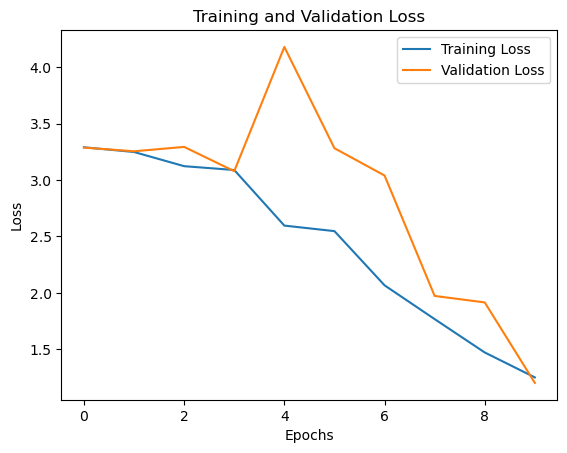

In [101]:
#Plot training and validation loss on y axis and epoch on x axis
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
#Sets the title of the plot 
plt.title('Training and Validation Loss')
#Sets the label of the x-axis 
plt.xlabel('Epochs')
#Sets the label of the y-axis 
plt.ylabel('Loss')
#Shows the legends of the plot
plt.legend()
#Shows the plot on the screen.
plt.show()

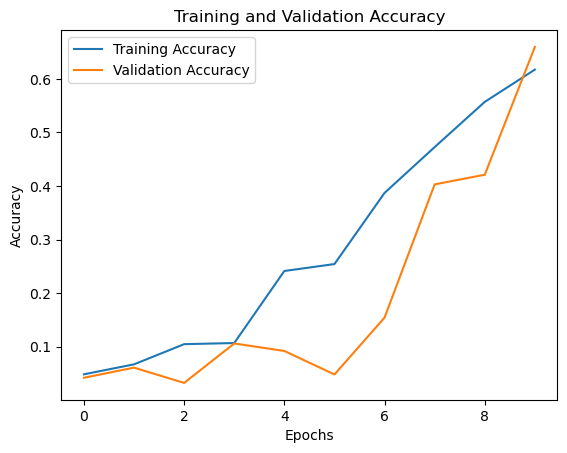

In [102]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
#Sets the title of the plot 
plt.title('Training and Validation Accuracy')
#Sets the label of the x-axis 
plt.xlabel('Epochs')
#Sets the label of the y-axis 
plt.ylabel('Accuracy')
#Shows the legend of the plot 
plt.legend()
#Shows the plot on the screen.
plt.show()

In [103]:
# Predict the classes of the test set
y_pred = np.argmax(model.predict(x_test), axis=-1)

72/72 [==============================] - 12s 161ms/step


In [104]:
# Print the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.60      0.60       104
           1       0.86      0.68      0.76        99
           2       0.69      0.63      0.66        82
           3       0.84      0.69      0.76        99
           4       0.52      0.58      0.54        85
           5       0.86      0.68      0.76        84
           6       0.48      0.61      0.54        87
           7       0.59      0.64      0.61        80
           8       0.70      0.59      0.64        91
           9       0.70      0.63      0.66        84
          10       0.63      0.57      0.60        30
          11       0.54      0.57      0.56        91
          12       0.75      0.39      0.51        85
          13       0.57      0.43      0.49        92
          14       0.73      0.77      0.75        86
          15       0.75      0.86      0.80        79
          16       0.52      0.47      0.49        94
          17       0.77    

<Figure size 25000x10000 with 0 Axes>

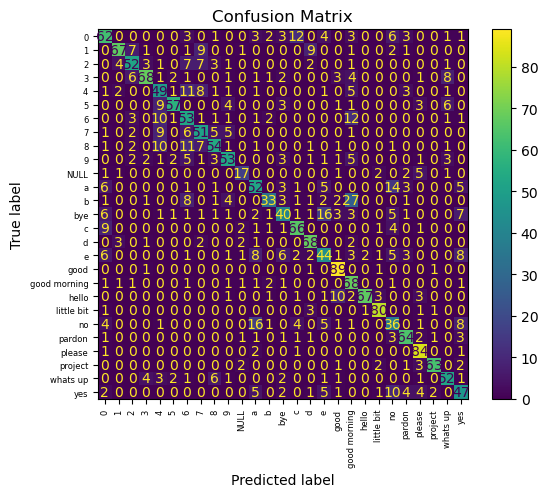

In [105]:
#Print the confusion Matrix
plt.figure(dpi=500, figsize=(50, 20))
cm = ConfusionMatrixDisplay.from_predictions(y_test,y_pred, display_labels=np.unique(y))
cm.ax_.tick_params(axis='x', labelsize=6)
cm.ax_.tick_params(axis='y', labelsize=6)
cm.ax_.set_xticklabels(cm.ax_.get_xticklabels(), rotation=90)
plt.title('Confusion Matrix')
plt.show()

#### Hyperparameter Optimization and Data Augmentation

Optimizer - ADAM

Augmented Data


In [17]:
# Create Model
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (3,3), padding = 'Same', activation = 'relu', input_shape = (x_train.shape[1:])))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Dropout(0.50))

model.add(Conv2D(filters = 32, kernel_size = (3,3), padding = 'Same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2)))
model.add(Dropout(0.50))

model.add(Conv2D(filters = 64, kernel_size = (3,3), padding = 'Same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2)))
model.add(Dropout(0.50))

model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = 'Same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2)))
model.add(Dropout(0.50))

model.add(Flatten())
model.add(Dense(128, activation = 'relu'))
model.add(Dense(64, activation = 'relu'))
model.add(Dense(number_classes, activation = 'softmax'))

# Define Optimizer
optimizer = Adam(learning_rate = 0.0001, beta_1=0.9, beta_2=0.999)

# Compile Model
model.compile(optimizer = optimizer, loss = "categorical_crossentropy", metrics = ["accuracy"])


In [18]:
#Summary of the model

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      2432      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 64, 64, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 32)        9248      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 32, 32, 32)       0         
 2D)                                                             
                                                                 
 dropout_1 (Dropout)         (None, 32, 32, 32)        0

In [21]:
#fit the augmented data in train_datagen.flow
history=model.fit(train_datagen.flow(x_train, keras.utils.to_categorical(y_train), 
                batch_size=200), epochs=10, 
                validation_data=(x_val, keras.utils.to_categorical(y_val)))

Epoch 1/10
92/92 [==============================] - 458s 5s/step - loss: 3.2914 - accuracy: 0.0394 - val_loss: 3.2946 - val_accuracy: 0.0329
Epoch 2/10
92/92 [==============================] - 401s 4s/step - loss: 3.2516 - accuracy: 0.0633 - val_loss: 3.2976 - val_accuracy: 0.0342
Epoch 3/10
92/92 [==============================] - 477s 5s/step - loss: 3.1111 - accuracy: 0.1002 - val_loss: 3.2119 - val_accuracy: 0.0947
Epoch 4/10
92/92 [==============================] - 391s 4s/step - loss: 2.8624 - accuracy: 0.1477 - val_loss: 2.8736 - val_accuracy: 0.2180
Epoch 5/10
92/92 [==============================] - 386s 4s/step - loss: 2.4435 - accuracy: 0.2456 - val_loss: 2.4255 - val_accuracy: 0.2443
Epoch 6/10
92/92 [==============================] - 381s 4s/step - loss: 2.0834 - accuracy: 0.3401 - val_loss: 1.9811 - val_accuracy: 0.3658
Epoch 7/10
92/92 [==============================] - 384s 4s/step - loss: 1.8815 - accuracy: 0.3956 - val_loss: 1.7528 - val_accuracy: 0.4482
Epoch 8/10
92

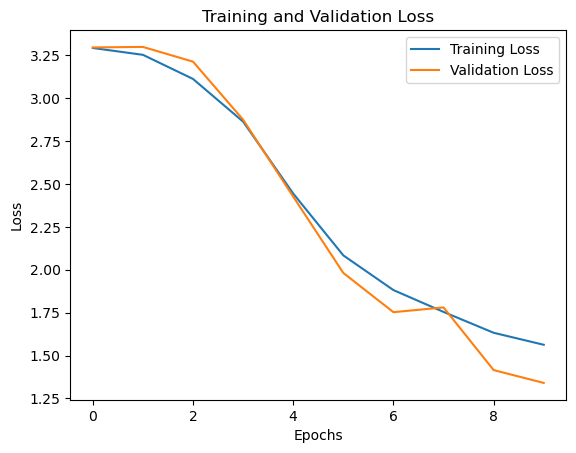

In [22]:
#Plot training and validation loss on y axis and epoch on x axis
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
#Sets the title of the plot 
plt.title('Training and Validation Loss')
#Sets the label of the x-axis 
plt.xlabel('Epochs')
#Sets the label of the y-axis 
plt.ylabel('Loss')
#Shows the legends of the plot
plt.legend()
#Shows the plot on the screen.
plt.show()

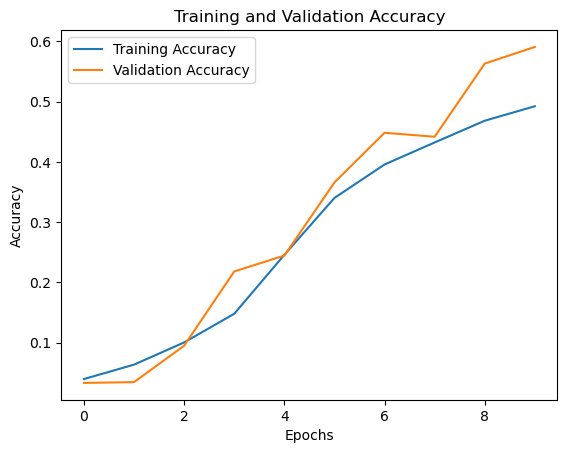

In [23]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
#Sets the title of the plot 
plt.title('Training and Validation Accuracy')
#Sets the label of the x-axis 
plt.xlabel('Epochs')
#Sets the label of the y-axis 
plt.ylabel('Accuracy')
#Shows the legend of the plot 
plt.legend()
#Shows the plot on the screen.
plt.show()

In [24]:
# Predict the classes of the test set
y_pred = np.argmax(model.predict(x_test), axis=-1)

72/72 [==============================] - 12s 149ms/step


In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.51      0.55       104
           1       0.90      0.77      0.83        99
           2       0.68      0.67      0.67        82
           3       0.75      0.64      0.69        99
           4       0.47      0.66      0.55        85
           5       0.61      0.82      0.70        84
           6       0.48      0.75      0.59        87
           7       0.46      0.60      0.52        80
           8       0.76      0.31      0.44        91
           9       0.61      0.20      0.30        84
          10       0.49      0.70      0.58        30
          11       0.62      0.41      0.49        91
          12       0.63      0.40      0.49        85
          13       0.62      0.45      0.52        92
          14       0.74      0.45      0.56        86
          15       0.82      0.85      0.83        79
          16       0.45      0.36      0.40        94
          17       0.92    

<Figure size 25000x10000 with 0 Axes>

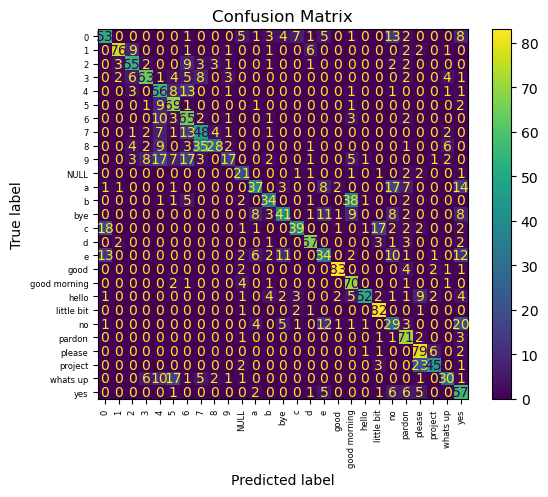

In [26]:
plt.figure(dpi=500, figsize=(50, 20))
cm = ConfusionMatrixDisplay.from_predictions(y_test,y_pred, display_labels=np.unique(y))
cm.ax_.tick_params(axis='x', labelsize=6)
cm.ax_.tick_params(axis='y', labelsize=6)
cm.ax_.set_xticklabels(cm.ax_.get_xticklabels(), rotation=90)
plt.title('Confusion Matrix')
plt.show()

## Hyperparameter Tuning

#### Increasing Learning Rate and Number of Epochs

In [36]:
# Create Model
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (3,3), padding = 'Same', activation = 'relu', input_shape = (x_train.shape[1:])))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Dropout(0.50))

model.add(Conv2D(filters = 32, kernel_size = (3,3), padding = 'Same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2)))
model.add(Dropout(0.50))

model.add(Conv2D(filters = 64, kernel_size = (3,3), padding = 'Same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2)))
model.add(Dropout(0.50))

model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = 'Same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2)))
model.add(Dropout(0.50))

model.add(Flatten())
model.add(Dense(128, activation = 'relu'))
model.add(Dense(64, activation = 'relu'))
model.add(Dense(number_classes, activation = 'softmax'))

# Define Optimizer
optimizer = Adam(learning_rate = 0.01, beta_1=0.9, beta_2=0.999)

# Compile Model
model.compile(optimizer = optimizer, loss = "categorical_crossentropy", metrics = ["accuracy"])


In [37]:
#Summary of the model

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_8 (Conv2D)           (None, 128, 128, 32)      2432      
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 64, 64, 32)       0         
 2D)                                                             
                                                                 
 dropout_8 (Dropout)         (None, 64, 64, 32)        0         
                                                                 
 conv2d_9 (Conv2D)           (None, 64, 64, 32)        9248      
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 32, 32, 32)       0         
 2D)                                                             
                                                                 
 dropout_9 (Dropout)         (None, 32, 32, 32)       

In [38]:
model.compile(optimizer = "adam", loss='categorical_crossentropy', metrics = ['accuracy'])

In [39]:
history=model.fit(train_datagen.flow(x_train, keras.utils.to_categorical(y_train), 
                batch_size=200), epochs=20, 
                validation_data=(x_val, keras.utils.to_categorical(y_val)))

Epoch 1/20
92/92 [==============================] - 351s 4s/step - loss: 3.2974 - accuracy: 0.0367 - val_loss: 3.2918 - val_accuracy: 0.0382
Epoch 2/20
92/92 [==============================] - 351s 4s/step - loss: 3.2826 - accuracy: 0.0481 - val_loss: 3.2915 - val_accuracy: 0.0355
Epoch 3/20
92/92 [==============================] - 373s 4s/step - loss: 3.2486 - accuracy: 0.0634 - val_loss: 3.3979 - val_accuracy: 0.0325
Epoch 4/20
92/92 [==============================] - 350s 4s/step - loss: 3.2106 - accuracy: 0.0673 - val_loss: 3.2795 - val_accuracy: 0.0412
Epoch 5/20
92/92 [==============================] - 352s 4s/step - loss: 3.1281 - accuracy: 0.0896 - val_loss: 3.1583 - val_accuracy: 0.0662
Epoch 6/20
92/92 [==============================] - 351s 4s/step - loss: 2.8867 - accuracy: 0.1380 - val_loss: 2.7968 - val_accuracy: 0.1746
Epoch 7/20
92/92 [==============================] - 349s 4s/step - loss: 2.6641 - accuracy: 0.1920 - val_loss: 2.5103 - val_accuracy: 0.2531
Epoch 8/20
92

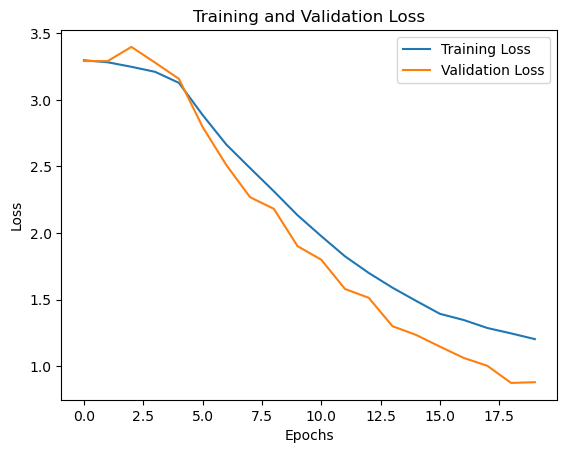

In [40]:
#Plot training and validation loss on y axis and epoch on x axis
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
#Sets the title of the plot 
plt.title('Training and Validation Loss')
#Sets the label of the x-axis 
plt.xlabel('Epochs')
#Sets the label of the y-axis 
plt.ylabel('Loss')
#Shows the legends of the plot
plt.legend()
#Shows the plot on the screen.
plt.show()

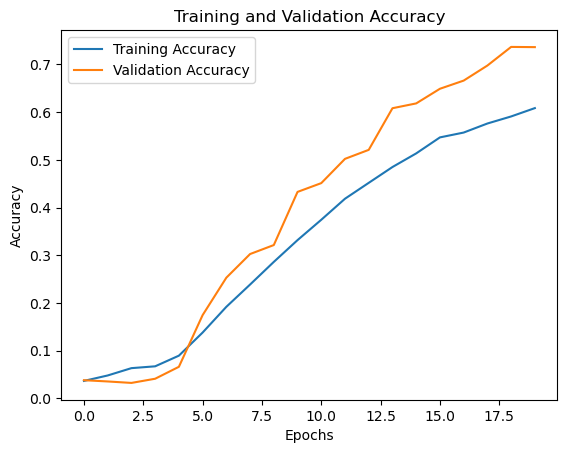

In [41]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
#Sets the title of the plot 
plt.title('Training and Validation Accuracy')
#Sets the label of the x-axis 
plt.xlabel('Epochs')
#Sets the label of the y-axis 
plt.ylabel('Accuracy')
#Shows the legend of the plot 
plt.legend()
#Shows the plot on the screen.
plt.show()

In [42]:
# Predict the classes of the test set
y_pred = np.argmax(model.predict(x_test), axis=-1)

72/72 [==============================] - 12s 165ms/step


In [43]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.83      0.82       104
           1       0.81      0.93      0.86        99
           2       0.88      0.71      0.78        82
           3       0.92      0.62      0.74        99
           4       0.89      0.47      0.62        85
           5       0.90      0.79      0.84        84
           6       0.47      0.76      0.58        87
           7       0.68      0.40      0.50        80
           8       0.75      0.54      0.63        91
           9       0.72      0.49      0.58        84
          10       0.71      0.57      0.63        30
          11       0.81      0.79      0.80        91
          12       0.51      0.87      0.64        85
          13       0.69      0.87      0.77        92
          14       0.81      0.72      0.76        86
          15       0.94      0.82      0.88        79
          16       0.78      0.62      0.69        94
          17       0.89    

<Figure size 25000x10000 with 0 Axes>

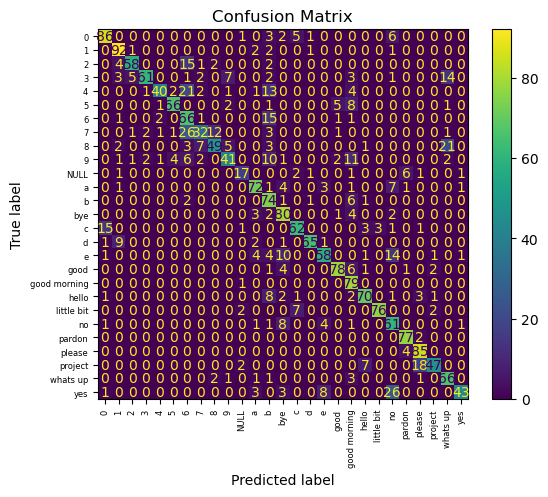

In [44]:
plt.figure(dpi=500, figsize=(50, 20))
cm = ConfusionMatrixDisplay.from_predictions(y_test,y_pred, display_labels=np.unique(y))
#cm.text_.set_fontsize(6)
cm.ax_.tick_params(axis='x', labelsize=6)
cm.ax_.tick_params(axis='y', labelsize=6)
cm.ax_.set_xticklabels(cm.ax_.get_xticklabels(), rotation=90)
plt.title('Confusion Matrix')
plt.show()

Increasing Kernel size

In [46]:
# Create Model
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (5,5), padding = 'Same', activation = 'relu', input_shape = (x_train.shape[1:])))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Dropout(0.50))

model.add(Conv2D(filters = 32, kernel_size = (5,5), padding = 'Same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2)))
model.add(Dropout(0.50))

model.add(Conv2D(filters = 64, kernel_size = (5,5), padding = 'Same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2)))
model.add(Dropout(0.50))

model.add(Conv2D(filters = 128, kernel_size = (5,5), padding = 'Same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2)))
model.add(Dropout(0.50))

model.add(Flatten())
model.add(Dense(128, activation = 'relu'))
model.add(Dense(64, activation = 'relu'))
model.add(Dense(number_classes, activation = 'softmax'))

# Define Optimizer
optimizer = Adam(learning_rate = 0.01, beta_1=0.9, beta_2=0.999)

# Compile Model
model.compile(optimizer = optimizer, loss = "categorical_crossentropy", metrics = ["accuracy"])


In [47]:
#Summary of the model

model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_12 (Conv2D)          (None, 128, 128, 32)      2432      
                                                                 
 max_pooling2d_12 (MaxPoolin  (None, 64, 64, 32)       0         
 g2D)                                                            
                                                                 
 dropout_12 (Dropout)        (None, 64, 64, 32)        0         
                                                                 
 conv2d_13 (Conv2D)          (None, 64, 64, 32)        25632     
                                                                 
 max_pooling2d_13 (MaxPoolin  (None, 32, 32, 32)       0         
 g2D)                                                            
                                                                 
 dropout_13 (Dropout)        (None, 32, 32, 32)       

In [48]:
model.compile(optimizer = "adam", loss='categorical_crossentropy', metrics = ['accuracy'])

In [49]:
history=model.fit(train_datagen.flow(x_train, keras.utils.to_categorical(y_train), 
                batch_size=200), epochs=20, 
                validation_data=(x_val, keras.utils.to_categorical(y_val)))

Epoch 1/20
92/92 [==============================] - 550s 6s/step - loss: 3.2942 - accuracy: 0.0389 - val_loss: 3.2916 - val_accuracy: 0.0316
Epoch 2/20
92/92 [==============================] - 550s 6s/step - loss: 3.2704 - accuracy: 0.0553 - val_loss: 3.2603 - val_accuracy: 0.0658
Epoch 3/20
92/92 [==============================] - 569s 6s/step - loss: 3.1488 - accuracy: 0.0884 - val_loss: 3.0865 - val_accuracy: 0.1197
Epoch 4/20
92/92 [==============================] - 558s 6s/step - loss: 2.9239 - accuracy: 0.1376 - val_loss: 2.7817 - val_accuracy: 0.1943
Epoch 5/20
92/92 [==============================] - 554s 6s/step - loss: 2.6264 - accuracy: 0.2019 - val_loss: 2.3766 - val_accuracy: 0.2969
Epoch 6/20
92/92 [==============================] - 557s 6s/step - loss: 2.2196 - accuracy: 0.3008 - val_loss: 1.7448 - val_accuracy: 0.4399
Epoch 7/20
92/92 [==============================] - 554s 6s/step - loss: 1.8875 - accuracy: 0.3937 - val_loss: 1.4619 - val_accuracy: 0.5224
Epoch 8/20
92

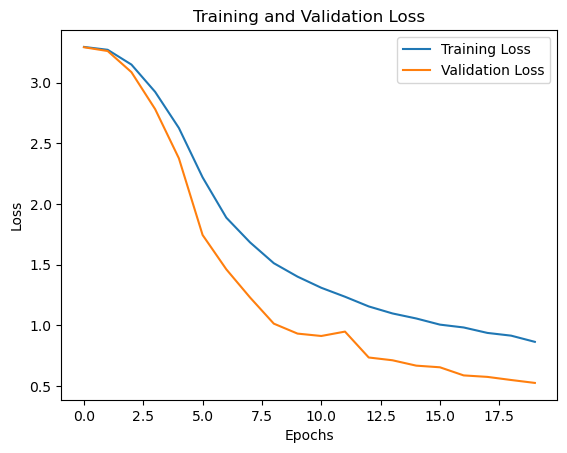

In [50]:
#Plot training and validation loss on y axis and epoch on x axis
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
#Sets the title of the plot 
plt.title('Training and Validation Loss')
#Sets the label of the x-axis 
plt.xlabel('Epochs')
#Sets the label of the y-axis 
plt.ylabel('Loss')
#Shows the legends of the plot
plt.legend()
#Shows the plot on the screen.
plt.show()

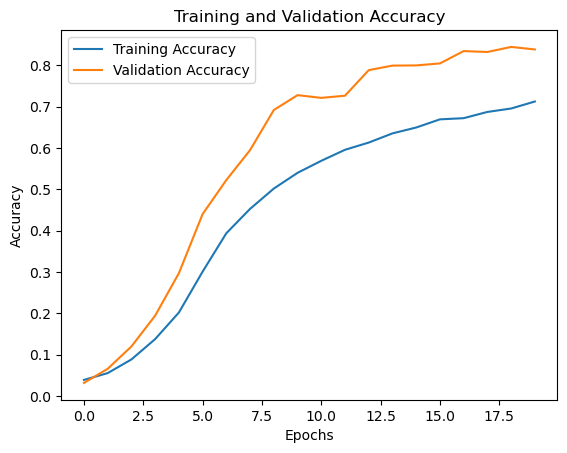

In [51]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
#Sets the title of the plot 
plt.title('Training and Validation Accuracy')
#Sets the label of the x-axis 
plt.xlabel('Epochs')
#Sets the label of the y-axis 
plt.ylabel('Accuracy')
#Shows the legend of the plot 
plt.legend()
#Shows the plot on the screen.
plt.show()

In [52]:
# Predict the classes of the test set
y_pred = np.argmax(model.predict(x_test), axis=-1)

72/72 [==============================] - 17s 241ms/step


In [53]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87       104
           1       0.95      0.95      0.95        99
           2       0.89      0.95      0.92        82
           3       0.98      0.84      0.90        99
           4       0.85      0.82      0.84        85
           5       0.96      0.93      0.95        84
           6       0.75      0.86      0.80        87
           7       0.79      0.68      0.73        80
           8       0.77      0.87      0.82        91
           9       0.92      0.80      0.85        84
          10       0.83      0.83      0.83        30
          11       0.92      0.85      0.88        91
          12       0.74      0.94      0.83        85
          13       0.81      0.90      0.86        92
          14       0.91      0.80      0.85        86
          15       0.96      0.90      0.93        79
          16       0.72      0.77      0.74        94
          17       0.99    

<Figure size 25000x10000 with 0 Axes>

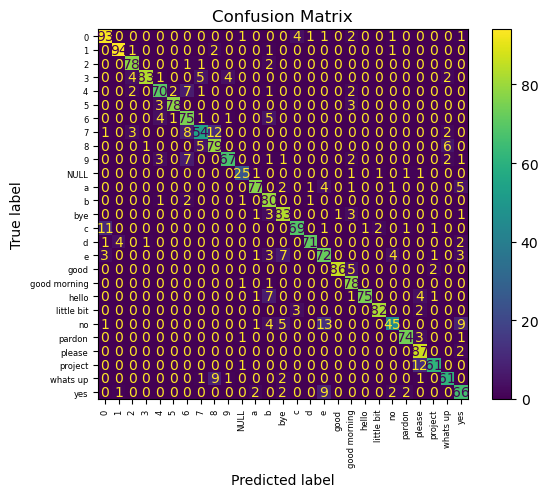

In [54]:
plt.figure(dpi=500, figsize=(50, 20))
cm = ConfusionMatrixDisplay.from_predictions(y_test,y_pred, display_labels=np.unique(y))
#cm.text_.set_fontsize(6)
cm.ax_.tick_params(axis='x', labelsize=6)
cm.ax_.tick_params(axis='y', labelsize=6)
cm.ax_.set_xticklabels(cm.ax_.get_xticklabels(), rotation=90)
plt.title('Confusion Matrix')
plt.show()

#### More Tuning

Increasing number of epochs to 50

In [55]:
# Create Model
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (5,5), padding = 'Same', activation = 'relu', input_shape = (x_train.shape[1:])))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Dropout(0.50))

model.add(Conv2D(filters = 32, kernel_size = (5,5), padding = 'Same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2)))
model.add(Dropout(0.50))

model.add(Conv2D(filters = 64, kernel_size = (5,5), padding = 'Same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2)))
model.add(Dropout(0.50))

model.add(Conv2D(filters = 128, kernel_size = (5,5), padding = 'Same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2)))
model.add(Dropout(0.50))

model.add(Flatten())
model.add(Dense(128, activation = 'relu'))
#model.add(Dense(64, activation = 'relu'))
model.add(Dense(number_classes, activation = 'softmax'))

# Define Optimizer
optimizer = Adam(learning_rate = 0.01, beta_1=0.9, beta_2=0.999)

# Compile Model
model.compile(optimizer = optimizer, loss = "categorical_crossentropy", metrics = ["accuracy"])

# Epochs And Batch Size
epochs = 20

In [56]:
#Summary of the model

model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_16 (Conv2D)          (None, 128, 128, 32)      2432      
                                                                 
 max_pooling2d_16 (MaxPoolin  (None, 64, 64, 32)       0         
 g2D)                                                            
                                                                 
 dropout_16 (Dropout)        (None, 64, 64, 32)        0         
                                                                 
 conv2d_17 (Conv2D)          (None, 64, 64, 32)        25632     
                                                                 
 max_pooling2d_17 (MaxPoolin  (None, 32, 32, 32)       0         
 g2D)                                                            
                                                                 
 dropout_17 (Dropout)        (None, 32, 32, 32)       

In [58]:
history=model.fit(train_datagen.flow(x_train, keras.utils.to_categorical(y_train), 
                batch_size=200), epochs=50, 
                validation_data=(x_val, keras.utils.to_categorical(y_val)))

Epoch 1/50
92/92 [==============================] - 572s 6s/step - loss: 3.2927 - accuracy: 0.0377 - val_loss: 3.2917 - val_accuracy: 0.0386
Epoch 2/50
92/92 [==============================] - 630s 7s/step - loss: 3.2695 - accuracy: 0.0578 - val_loss: 3.2790 - val_accuracy: 0.0447
Epoch 3/50
92/92 [==============================] - 575s 6s/step - loss: 3.1502 - accuracy: 0.0894 - val_loss: 3.2002 - val_accuracy: 0.1096
Epoch 4/50
92/92 [==============================] - 627s 7s/step - loss: 2.8435 - accuracy: 0.1564 - val_loss: 2.7733 - val_accuracy: 0.2070
Epoch 5/50
92/92 [==============================] - 571s 6s/step - loss: 2.3798 - accuracy: 0.2720 - val_loss: 2.0162 - val_accuracy: 0.4044
Epoch 6/50
92/92 [==============================] - 585s 6s/step - loss: 1.9261 - accuracy: 0.3892 - val_loss: 1.4756 - val_accuracy: 0.5882
Epoch 7/50
92/92 [==============================] - 636s 7s/step - loss: 1.6368 - accuracy: 0.4703 - val_loss: 1.2482 - val_accuracy: 0.6680
Epoch 8/50
92

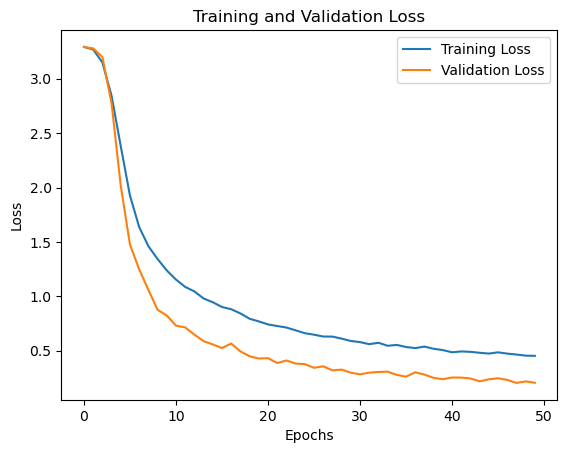

In [59]:
#Plot training and validation loss on y axis and epoch on x axis
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
#Sets the title of the plot 
plt.title('Training and Validation Loss')
#Sets the label of the x-axis 
plt.xlabel('Epochs')
#Sets the label of the y-axis 
plt.ylabel('Loss')
#Shows the legends of the plot
plt.legend()
#Shows the plot on the screen.
plt.show()

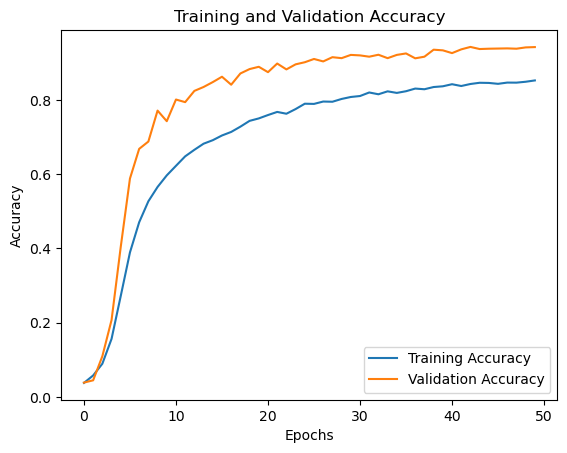

In [60]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
#Sets the title of the plot 
plt.title('Training and Validation Accuracy')
#Sets the label of the x-axis 
plt.xlabel('Epochs')
#Sets the label of the y-axis 
plt.ylabel('Accuracy')
#Shows the legend of the plot 
plt.legend()
#Shows the plot on the screen.
plt.show()

In [61]:
# Predict the classes of the test set
y_pred = np.argmax(model.predict(x_test), axis=-1)

72/72 [==============================] - 24s 323ms/step


In [62]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95       104
           1       0.97      0.96      0.96        99
           2       0.97      0.94      0.96        82
           3       0.99      0.97      0.98        99
           4       0.92      0.95      0.94        85
           5       0.98      1.00      0.99        84
           6       0.96      0.91      0.93        87
           7       0.94      0.93      0.93        80
           8       0.93      0.99      0.96        91
           9       0.99      0.98      0.98        84
          10       0.72      0.87      0.79        30
          11       0.98      0.99      0.98        91
          12       0.82      0.94      0.88        85
          13       0.99      0.97      0.98        92
          14       0.93      0.91      0.92        86
          15       0.97      0.95      0.96        79
          16       0.88      0.94      0.91        94
          17       0.99    

<Figure size 4000x2000 with 0 Axes>

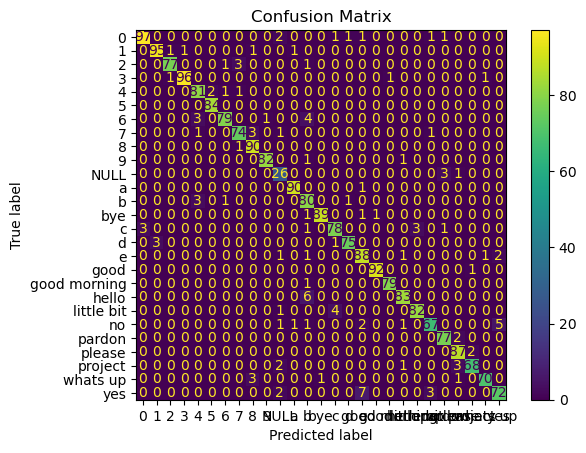

In [63]:

# # y_pred_classes = np.argmax(y_pred,axis = 1) 
# # y_true = np.argmax(y_test,axis = 1) 
# cm = confusion_matrix(y_test, y_pred) 
# sns.heatmap(cm, annot=True,cmap="Greens")
# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.title("Confusion Matrix")
# plt.show()


plt.figure(dpi=200, figsize=(20, 10))
ConfusionMatrixDisplay.from_predictions(y_test,y_pred, display_labels=np.unique(y))
plt.title('Confusion Matrix')
plt.show()

## Hyperparameter Tuning

#### Increasing Number of Epochs and Introducing Early Stopping

In [64]:
from tensorflow.keras.callbacks import EarlyStopping

In [84]:
# Create Model
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (5,5), padding = 'Same', activation = 'relu', input_shape = (x_train.shape[1:])))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Dropout(0.50))

model.add(Conv2D(filters = 32, kernel_size = (5,5), padding = 'Same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2)))
model.add(Dropout(0.50))

model.add(Conv2D(filters = 64, kernel_size = (5,5), padding = 'Same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2)))
model.add(Dropout(0.50))

model.add(Conv2D(filters = 128, kernel_size = (5,5), padding = 'Same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2)))
model.add(Dropout(0.50))

model.add(Flatten())
model.add(Dense(128, activation = 'relu'))
model.add(Dense(64, activation = 'relu'))
model.add(Dense(number_classes, activation = 'softmax'))

# Define Optimizer
optimizer = Adam(learning_rate = 0.01, beta_1=0.9, beta_2=0.999)

#Define early stopping
early_stopping = EarlyStopping(
    monitor='val_accuracy',  # The metrics to monitor
    patience=5,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  #restore the best epoch
)

# Compile Model
model.compile(optimizer = optimizer, loss = "categorical_crossentropy", metrics = ["accuracy"])



In [85]:
#Summary of the model

model.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_36 (Conv2D)          (None, 128, 128, 32)      2432      
                                                                 
 max_pooling2d_36 (MaxPoolin  (None, 64, 64, 32)       0         
 g2D)                                                            
                                                                 
 dropout_36 (Dropout)        (None, 64, 64, 32)        0         
                                                                 
 conv2d_37 (Conv2D)          (None, 64, 64, 32)        25632     
                                                                 
 max_pooling2d_37 (MaxPoolin  (None, 32, 32, 32)       0         
 g2D)                                                            
                                                                 
 dropout_37 (Dropout)        (None, 32, 32, 32)       

In [89]:
model.compile(optimizer = "adam", loss='categorical_crossentropy', metrics = ['accuracy'])

In [91]:
history=model.fit(x_train, keras.utils.to_categorical(y_train), 
                epochs=80, 
                validation_data=(x_val, keras.utils.to_categorical(y_val)), 
                callbacks=[early_stopping])
#the model will be trained

Epoch 1/80
571/571 [==============================] - 597s 1s/step - loss: 3.2874 - accuracy: 0.0377 - val_loss: 3.2843 - val_accuracy: 0.0395
Epoch 2/80
571/571 [==============================] - 599s 1s/step - loss: 3.2872 - accuracy: 0.0380 - val_loss: 3.2841 - val_accuracy: 0.0329
Epoch 3/80
571/571 [==============================] - 611s 1s/step - loss: 3.2866 - accuracy: 0.0400 - val_loss: 3.2843 - val_accuracy: 0.0281
Epoch 4/80
571/571 [==============================] - 615s 1s/step - loss: 3.2858 - accuracy: 0.0422 - val_loss: 3.2808 - val_accuracy: 0.0439
Epoch 5/80
571/571 [==============================] - 627s 1s/step - loss: 3.2811 - accuracy: 0.0444 - val_loss: 3.2729 - val_accuracy: 0.0417
Epoch 6/80
571/571 [==============================] - 685s 1s/step - loss: 3.2766 - accuracy: 0.0486 - val_loss: 3.2677 - val_accuracy: 0.0496
Epoch 7/80
571/571 [==============================] - 607s 1s/step - loss: 3.2655 - accuracy: 0.0484 - val_loss: 3.2516 - val_accuracy: 0.0539

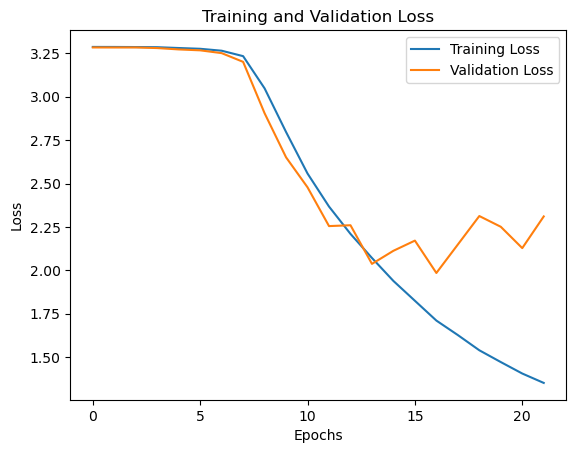

In [92]:
#Plot training and validation loss on y axis and epoch on x axis
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
#Sets the title of the plot 
plt.title('Training and Validation Loss')
#Sets the label of the x-axis 
plt.xlabel('Epochs')
#Sets the label of the y-axis 
plt.ylabel('Loss')
#Shows the legends of the plot
plt.legend()
#Shows the plot on the screen.
plt.show()

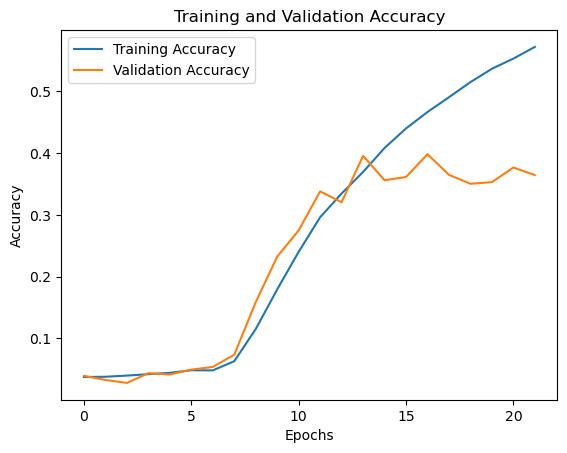

In [93]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
#Sets the title of the plot 
plt.title('Training and Validation Accuracy')
#Sets the label of the x-axis 
plt.xlabel('Epochs')
#Sets the label of the y-axis 
plt.ylabel('Accuracy')
#Shows the legend of the plot 
plt.legend()
#Shows the plot on the screen.
plt.show()

In [94]:
# Predict the classes of the test set
y_pred = np.argmax(model.predict(x_test), axis=-1)

72/72 [==============================] - 23s 315ms/step


In [95]:
# Evaluate your model on the test set
test_loss, test_accuracy = model.evaluate(x_test, keras.utils.to_categorical(y_test))
print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

72/72 [==============================] - 21s 294ms/step - loss: 1.9628 - accuracy: 0.4237
Test loss: 1.9627951383590698
Test accuracy: 0.4236842095851898


In [96]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.31      0.34      0.32       104
           1       0.55      0.24      0.34        99
           2       0.56      0.27      0.36        82
           3       0.64      0.37      0.47        99
           4       0.67      0.07      0.13        85
           5       0.46      0.45      0.46        84
           6       0.69      0.13      0.21        87
           7       0.38      0.12      0.19        80
           8       0.57      0.18      0.27        91
           9       0.37      0.13      0.19        84
          10       0.12      0.07      0.09        30
          11       0.30      0.60      0.40        91
          12       0.28      0.38      0.32        85
          13       0.23      0.62      0.33        92
          14       0.41      0.71      0.52        86
          15       0.70      0.61      0.65        79
          16       0.22      0.14      0.17        94
          17       0.49    

In [97]:
from sklearn.metrics import confusion_matrix


<Figure size 25000x10000 with 0 Axes>

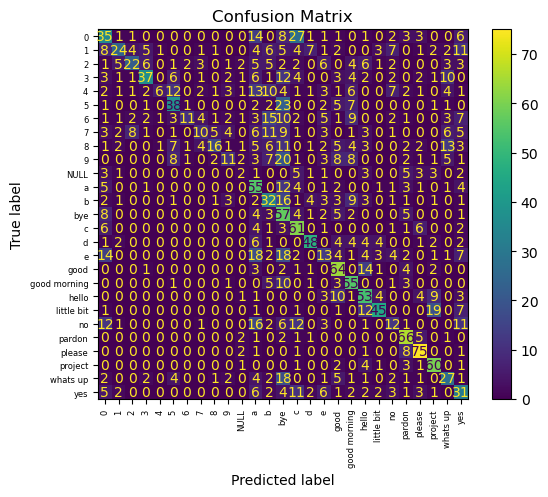

In [98]:


plt.figure(dpi=500, figsize=(50, 20))
cm = ConfusionMatrixDisplay.from_predictions(y_test,y_pred, display_labels=np.unique(y))
#cm.text_.set_fontsize(6)
cm.ax_.tick_params(axis='x', labelsize=6)
cm.ax_.tick_params(axis='y', labelsize=6)
cm.ax_.set_xticklabels(cm.ax_.get_xticklabels(), rotation=90)
plt.title('Confusion Matrix')
plt.show()

Notes

All ideas for codes have been gotten grom one of the following:
    
1. Codes used in the class notebooks
2. Codes used in other courses in this M.Sc 
3. https://pandas.pydata.org/docs/reference/index.html/ 
4. https://seaborn.pydata.org/
5. https://scikit-learn.org/stable/
